   user_id day_type  work_hours  screen_time_hours  meetings_count  \
0        1  Weekday        9.59              11.86               4   
1        1  Weekend        7.38              10.33               4   
2        1  Weekend        6.31               8.92               1   
3        1  Weekday        8.34              10.70               4   
4        1  Weekend        6.97               9.83               1   

   breaks_taken  after_hours_work  sleep_hours  task_completion_rate  \
0             2                 0         7.55                  91.2   
1             1                 0         6.69                  82.0   
2             2                 0         8.87                  80.6   
3             1                 1         8.13                  70.0   
4             2                 0         5.85                  67.1   

   burnout_score burnout_risk  
0          19.17          Low  
1          29.70          Low  
2          32.93          Low  
3          45.47  

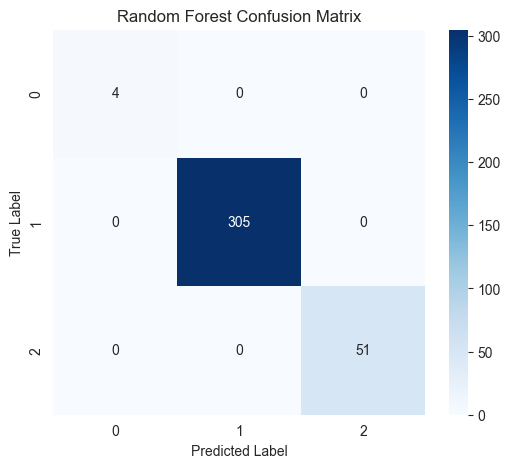


=== SVM ===
Test accuracy: 0.967
              precision    recall  f1-score   support

        High       1.00      0.50      0.67         4
         Low       1.00      0.97      0.98       305
      Medium       0.82      0.98      0.89        51

    accuracy                           0.97       360
   macro avg       0.94      0.82      0.85       360
weighted avg       0.97      0.97      0.97       360



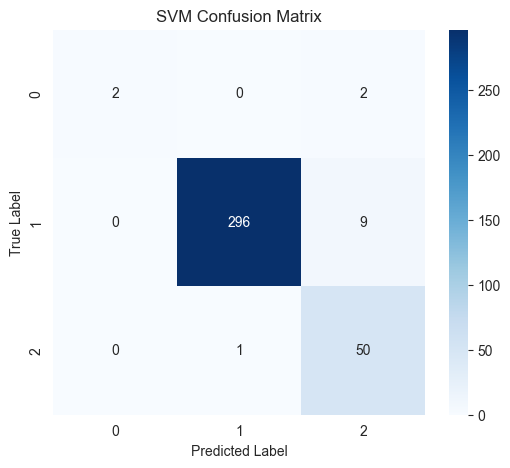


=== KNN ===
Test accuracy: 0.944
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         4
         Low       0.96      0.99      0.97       305
      Medium       0.86      0.73      0.79        51

    accuracy                           0.94       360
   macro avg       0.61      0.57      0.59       360
weighted avg       0.93      0.94      0.94       360



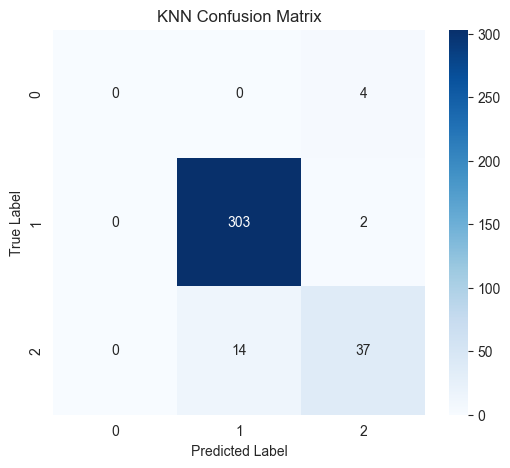


=== Logistic Regression ===
Test accuracy: 0.967
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         4
         Low       1.00      0.96      0.98       305
      Medium       0.82      0.98      0.89        51

    accuracy                           0.97       360
   macro avg       0.94      0.98      0.96       360
weighted avg       0.97      0.97      0.97       360



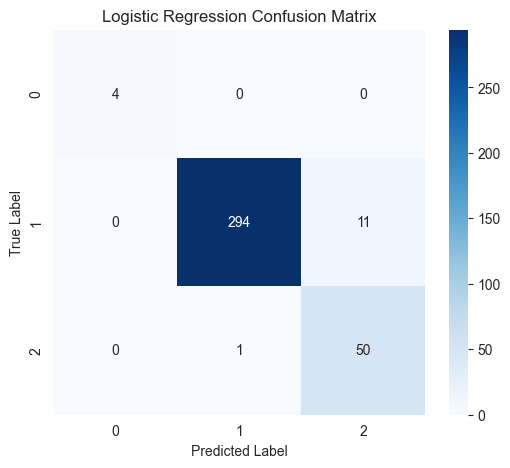

Top-10 важных признаков:
burnout_score: 0.5960
task_completion_rate: 0.3732
work_hours: 0.0081
screen_time_hours: 0.0061
sleep_hours: 0.0060
user_id: 0.0057
meetings_count: 0.0020
breaks_taken: 0.0019
day_type: 0.0005
after_hours_work: 0.0005


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ===== Путь к скачанному датасету =====
dataset_path = "data/work_from_home_burnout_dataset.csv"  # замените на реальный путь к CSV

# ===== Загрузка =====
df = pd.read_csv(dataset_path)
print(df.head())
print(df.info())

# ===== Обработка категориальных признаков =====
# Определяем целевую переменную (например, 'Burnout') и признаки
target_col = "burnout_risk"  # замените на реальный столбец с метками
X = df.drop(target_col, axis=1)
y = df[target_col]

# Преобразуем категориальные признаки в числа
for col in X.select_dtypes(include=['object', 'str']).columns:
    X[col] = LabelEncoder().fit_transform(X[col])

# Преобразуем метки в числа, если они категориальные
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# ===== Разделение на train/test =====
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, stratify=y, random_state=42
)

# ===== Стандартизация =====
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===== Модели =====
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
    "SVM": SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
}

# ===== Обучение и оценка =====
for name, model in models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# ===== Feature importance (Random Forest) =====
rf = models["Random Forest"]
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
print("Top-10 важных признаков:")
for i in indices[:10]:
    print(f"{X.columns[i]}: {importances[i]:.4f}")

=== Первые 5 строк ===
       bug_id                                       title  \
0  BUG_000001                  API Bug detected in system   
1  BUG_000002              Memory Leak detected in system   
2  BUG_000003  Cloud Configuration Bug detected in system   
3  BUG_000004       Authentication Bug detected in system   
4  BUG_000005              Logging Bug detected in system   

                                         description  error_code  \
0  This issue relates to a api bug occurring in t...       403.0   
1  This issue relates to a memory leak occurring ...       500.0   
2  This issue relates to a cloud configuration bu...       404.0   
3  This issue relates to a authentication bug occ...       404.0   
4  This issue relates to a logging bug occurring ...       503.0   

              bug_category       bug_domain   tech_stack severity  \
0                  API Bug           Mobile  Spring Boot     High   
1              Memory Leak             Data          GCP   Medi

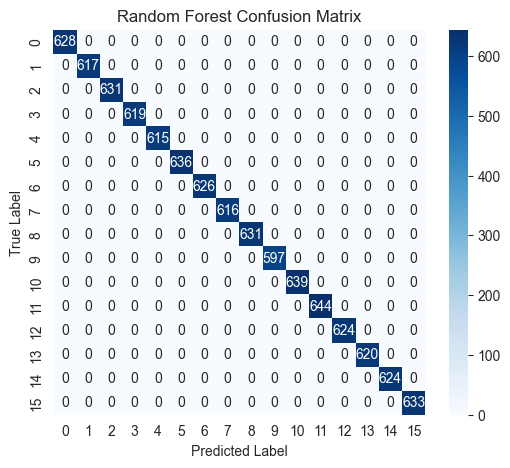


=== SVM ===


ValueError: Input X contains NaN.
SVC does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ===== Путь к скачанному датасету =====
dataset_path = "data/bug_dataset_50k.csv"  # замените на реальный путь к CSV

# ===== Загрузка =====
df = pd.read_csv(dataset_path)
print("=== Первые 5 строк ===")
print(df.head())
print(df.info())

print("Количество значений по столбцам")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} уникальных значений")

# ===== Обработка категориальных признаков =====
target_col = "bug_category"  # замените на реальный столбец с метками багов
X = df.drop(target_col, axis=1)
y = df[target_col]

# Преобразуем категориальные признаки в числа
for col in X.select_dtypes(include=['object', 'str']).columns:
    X[col] = LabelEncoder().fit_transform(X[col])

# Преобразуем метки в числа
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# ===== Разделение на train/test =====
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, stratify=y, random_state=42
)

# ===== Стандартизация =====
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===== Модели =====
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
    "SVM": SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
}

# ===== Обучение и оценка =====
for name, model in models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# ===== Feature importance (Random Forest) =====
rf = models["Random Forest"]
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
print("Top-10 важных признаков:")
for i in indices[:10]:
    print(f"{X.columns[i]}: {importances[i]:.4f}")

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

# --- Загрузка данных ---
df = pd.read_csv("data/bug_dataset_50k.csv")  # замените на свой путь

# --- Выбираем целевую колонку ---
target_col = "bug_category"  # настоящая метка

print(df.info())

# --- Исключаем колонки, которые утекали бы информацию ---
drop_cols = [
    'bug_id', 'title', 'description', 'root_cause',
    'suggested_fix', 'explanation', 'created_at'
]
X = df.drop(columns=drop_cols)
y = df[target_col]

print("!!!!!!!!!!!!!!!!!!!!!!!!!{EQ!!!!!!!!!!!!!!!!!!!")
print(X.info())

# --- Заполняем пропуски ---
X['error_code'] = X['error_code'].fillna(-1)  # для числового признака
X = X.fillna('Unknown')  # для категориальных

# --- Определяем категориальные и числовые признаки ---
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# --- Колонн-трансформер ---
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features)
])

# --- Разделяем на train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Random Forest ---
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("=== Random Forest ===")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(classification_report(y_test, y_pred_rf))

# --- SVM ---
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', random_state=42))
])

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

print("=== SVM ===")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_svm):.3f}")
print(classification_report(y_test, y_pred_svm))